# Credit Card Fraud Detection using Machine Learning

---

# Business Understanding

## Problem Statement

Credit card fraud has become one of the most significant challenges faced by financial institutions worldwide. Every fraudulent transaction results in financial losses for banks and merchants while also negatively impacting customer trust and satisfaction.

The objective of this project is to build a machine learning model capable of accurately identifying fraudulent credit card transactions.

Unlike traditional binary classification problems, fraud detection presents several unique challenges:

- The dataset is **extremely imbalanced**, with fraudulent transactions accounting for only **0.172%** of all observations.
- Missing a fraudulent transaction (False Negative) is usually much more expensive than incorrectly flagging a legitimate transaction (False Positive).
- Conventional evaluation metrics such as Accuracy become misleading because a model predicting every transaction as legitimate would still achieve more than **99.8% accuracy**.

Therefore, this project emphasizes metrics such as:

- Precision
- Recall
- F1 Score
- ROC-AUC
- Precision-Recall AUC (Primary Metric)

rather than relying solely on accuracy.

---

# Objectives

The primary objectives of this project are:

1. Perform extensive Exploratory Data Analysis (EDA).
2. Understand transaction behaviour.
3. Identify important predictive features.
4. Engineer meaningful features.
5. Handle severe class imbalance.
6. Compare multiple machine learning algorithms.
7. Perform hyperparameter tuning.
8. Analyse model errors.
9. Provide business recommendations based on the results.

---

# Dataset Description

The dataset contains credit card transactions made by European cardholders during September 2013.

### Dataset Statistics

|Property|Value|
|---------|------|
|Transactions|284,807|
|Fraud Transactions|492|
|Legitimate Transactions|284,315|
|Fraud Percentage|0.172%|

### Features

The dataset consists of 31 columns.

- **Time** : Seconds elapsed between each transaction and the first transaction.
- **Amount** : Transaction amount.
- **V1–V28** : Principal Components obtained after applying PCA.
- **Class** : Target Variable.

Target values:

- 0 → Legitimate Transaction
- 1 → Fraudulent Transaction

---

# Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

# Load Dataset

In [2]:
df = pd.read_csv("Dataset/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


# Dataset Dimensions

In [3]:
print("DATASET DIMENSIONS")

print(f"Number of Rows      : {df.shape[0]:,}")
print(f"Number of Columns   : {df.shape[1]}")

DATASET DIMENSIONS
Number of Rows      : 284,807
Number of Columns   : 31


## Observation

The dataset contains nearly **285 thousand transactions**, making it sufficiently large for training machine learning models while remaining computationally manageable on consumer hardware.

Among the 31 variables, 30 are predictor variables and one is the target variable (`Class`).

# Dataset Information

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

## Observation

From the dataset information, we observe:

- Every feature is numerical.
- No categorical variables are present.
- The target variable (`Class`) is stored as an integer.
- Most predictor variables are floating-point numbers.
- The dataset occupies a manageable amount of memory.
- The dataset does not contain null values.

Since all features are already numeric, no categorical encoding techniques such as One-Hot Encoding or Label Encoding are required.

# Descriptive Statistics

Descriptive statistics summarize the numerical characteristics of each feature.

Important statistics include:

- Mean
- Standard Deviation
- Minimum
- Quartiles
- Maximum

These statistics help identify:

- Outliers
- Skewed distributions
- Scaling requirements
- Data quality issues

In [5]:
summary = df.describe().T
summary

,count,mean,std,min,25%,50%,75%,max
Time,284807.0000,94813.8596,47488.1460,0.0000,54201.5000,84692.0000,139320.5000,172792.0000
V1,284807.0000,0.0000,1.9587,-56.4075,-0.9204,0.0181,1.3156,2.4549
V2,284807.0000,0.0000,1.6513,-72.7157,-0.5985,0.0655,0.8037,22.0577
V3,284807.0000,-0.0000,1.5163,-48.3256,-0.8904,0.1798,1.0272,9.3826
V4,284807.0000,0.0000,1.4159,-5.6832,-0.8486,-0.0198,0.7433,16.8753
V5,284807.0000,0.0000,1.3802,-113.7433,-0.6916,-0.0543,0.6119,34.8017
V6,284807.0000,0.0000,1.3323,-26.1605,-0.7683,-0.2742,0.3986,73.3016
V7,284807.0000,-0.0000,1.2371,-43.5572,-0.5541,0.0401,0.5704,120.5895
V8,284807.0000,0.0000,1.1944,-73.2167,-0.2086,0.0224,0.3273,20.0072
V9,284807.0000,-0.0000,1.0986,-13.4341,-0.6431,-0.0514,0.5971,15.5950


## Initial Observations

### Time

The **Time** feature ranges from **0 seconds** to approximately **172,792 seconds**, confirming that the dataset spans nearly **48 hours** of transaction activity.

---

### Amount

The **Amount** feature exhibits a large gap between its median and maximum value, indicating a highly **right-skewed distribution**.

This suggests the presence of significant outliers and indicates that **RobustScaler** may be more suitable than StandardScaler during preprocessing.

---

### PCA Features

Features **V1–V28** are principal components generated using Principal Component Analysis (PCA).

Since PCA typically produces standardized components with means close to zero and similar variances, these features generally do not require additional scaling.

# Missing Value Analysis

In [6]:
# Number of missing values in each feature

missing_values = df.isnull().sum()

# Total missing values

total_missing = missing_values.sum()

print("TOTAL MISSING VALUES")

print(total_missing)

TOTAL MISSING VALUES
0


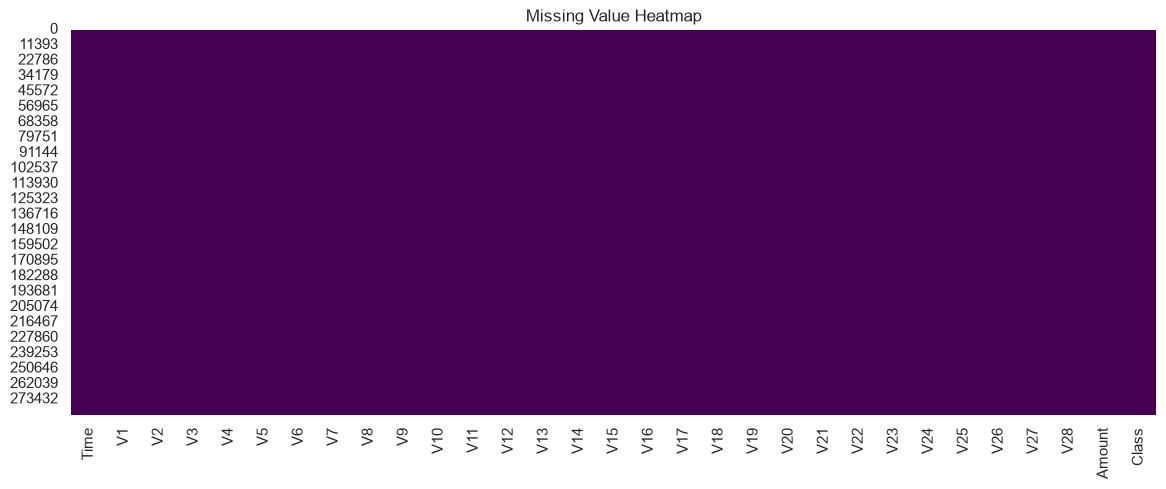

In [7]:
# Visualize Missing Values

plt.figure(figsize=(14,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.show()

## Observation

The analysis reveals that **no missing values** are present in the dataset.

This is a significant advantage because:

- No imputation techniques are required.
- No observations need to be discarded.
- The integrity of the original dataset is preserved.

# Duplicate Record Analysis
Duplicate transactions may bias machine learning models by artificially increasing the frequency of certain observations.

In [8]:
duplicate_rows = df.duplicated().sum()

print("DUPLICATE RECORDS")
print(f"Duplicate Rows : {duplicate_rows}")

DUPLICATE RECORDS
Duplicate Rows : 1081


In [9]:
duplicate_percentage = duplicate_rows/len(df)*100
print(f"Duplicate Percentage : {duplicate_percentage:.4f}%")

Duplicate Percentage : 0.3796%


In [10]:
# Display duplicate transactions
duplicates = df[df.duplicated()]
duplicates.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
33,26.0000,-0.5299,0.8739,1.3472,0.1455,0.4142,0.1002,0.7112,0.1761,-0.2867,-0.4847,0.8725,0.8516,-0.5717,0.1010,-1.5198,-0.2844,-0.3105,-0.4042,-0.8234,-0.2903,0.0469,0.2081,-0.1855,0.0010,0.0988,-0.5529,-0.0733,0.0233,6.1400,0
35,26.0000,-0.5354,0.8653,1.3511,0.1476,0.4337,0.0870,0.6930,0.1797,-0.2856,-0.4825,0.8718,0.8534,-0.5718,0.1023,-1.5200,-0.2859,-0.3096,-0.4039,-0.8237,-0.2833,0.0495,0.2065,-0.1871,0.0008,0.0981,-0.5535,-0.0783,0.0254,1.7700,0
113,74.0000,1.0384,0.1275,0.1845,1.1099,0.4417,0.9453,-0.0367,0.3510,0.1189,-0.2433,0.5781,0.6747,-0.5342,0.4466,1.1229,-1.7680,1.2412,-2.4495,-1.7473,-0.3355,0.1025,0.6051,0.0231,-0.6265,0.4791,-0.1669,0.0812,0.0012,1.1800,0
114,74.0000,1.0384,0.1275,0.1845,1.1099,0.4417,0.9453,-0.0367,0.3510,0.1189,-0.2433,0.5781,0.6747,-0.5342,0.4466,1.1229,-1.7680,1.2412,-2.4495,-1.7473,-0.3355,0.1025,0.6051,0.0231,-0.6265,0.4791,-0.1669,0.0812,0.0012,1.1800,0
115,74.0000,1.0384,0.1275,0.1845,1.1099,0.4417,0.9453,-0.0367,0.3510,0.1189,-0.2433,0.5781,0.6747,-0.5342,0.4466,1.1229,-1.7680,1.2412,-2.4495,-1.7473,-0.3355,0.1025,0.6051,0.0231,-0.6265,0.4791,-0.1669,0.0812,0.0012,1.1800,0


In [11]:
# Fraud distribution among duplicate rows
duplicates["Class"].value_counts()

Class
0    1062
1      19
Name: count, dtype: int64

## Observation

The dataset contains duplicate observations.

However, before removing them, it is important to understand whether they correspond to:

- legitimate repeated transactions, or
- duplicated entries introduced during data collection.

Blindly removing duplicate rows may accidentally remove valid fraudulent transactions, which are already extremely rare.

For the purpose of this project, the duplicate records will be retained to preserve potentially valuable fraud patterns.

# Target Variable Analysis

In [12]:
class_counts = df["Class"].value_counts()
class_counts

Class
0    284315
1       492
Name: count, dtype: int64

In [13]:
class_percentage = df["Class"].value_counts(normalize=True)*100
class_percentage

Class
0   99.8273
1    0.1727
Name: proportion, dtype: float64

In [14]:
class_summary = pd.DataFrame({
    "Count":class_counts,
    "Percentage":class_percentage
})

class_summary

,Count,Percentage
Class,,
0,284315,99.8273
1,492,0.1727


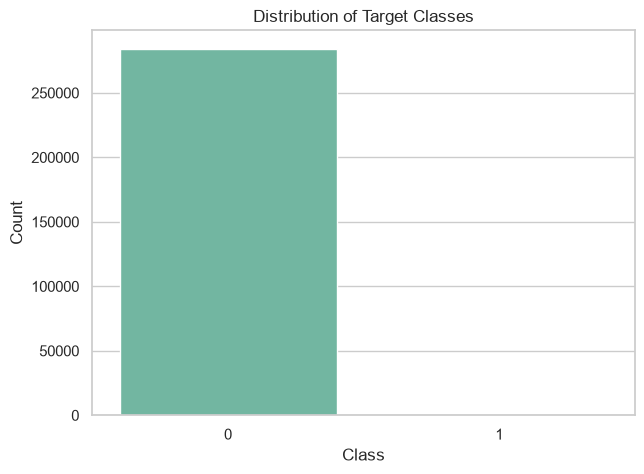

In [15]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Class",
    palette="Set2"
)

plt.title("Distribution of Target Classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

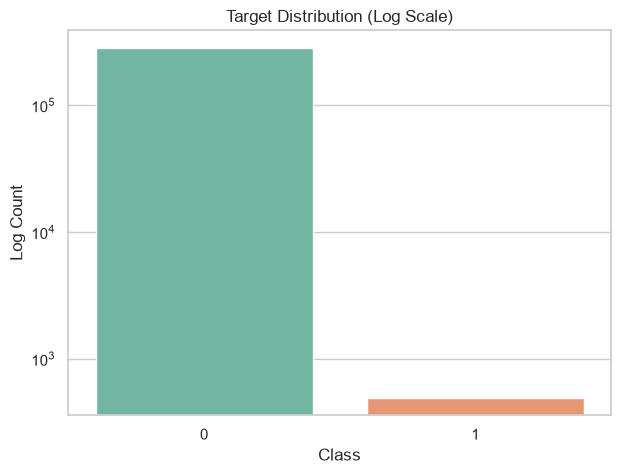

In [16]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Class",
    palette="Set2"
)

plt.yscale("log")
plt.title("Target Distribution (Log Scale)")
plt.xlabel("Class")
plt.ylabel("Log Count")
plt.show()

## Observation

The dataset is **extremely imbalanced**.

Approximately:

- **99.828%** of transactions are legitimate.
- **0.172%** are fraudulent.

This imbalance has important implications for model development:

1. Accuracy is not an appropriate evaluation metric.

A naive classifier predicting every transaction as legitimate would achieve nearly **99.8% accuracy** while completely failing to detect fraud.

2. The minority class must be handled carefully during training.

Techniques such as **SMOTE**, class weighting, or other resampling strategies will be explored later in the project.

3. Model performance should be evaluated using metrics that focus on the minority class, including:

- Precision
- Recall
- F1-score
- ROC-AUC
- **Precision-Recall AUC (Primary Metric)**

These metrics provide a much more meaningful assessment of fraud detection performance than overall accuracy.

# Exploratory Data Analysis(EDA)

# Distribution of Transaction Amount
The **Amount** feature represents the monetary value of each transaction.

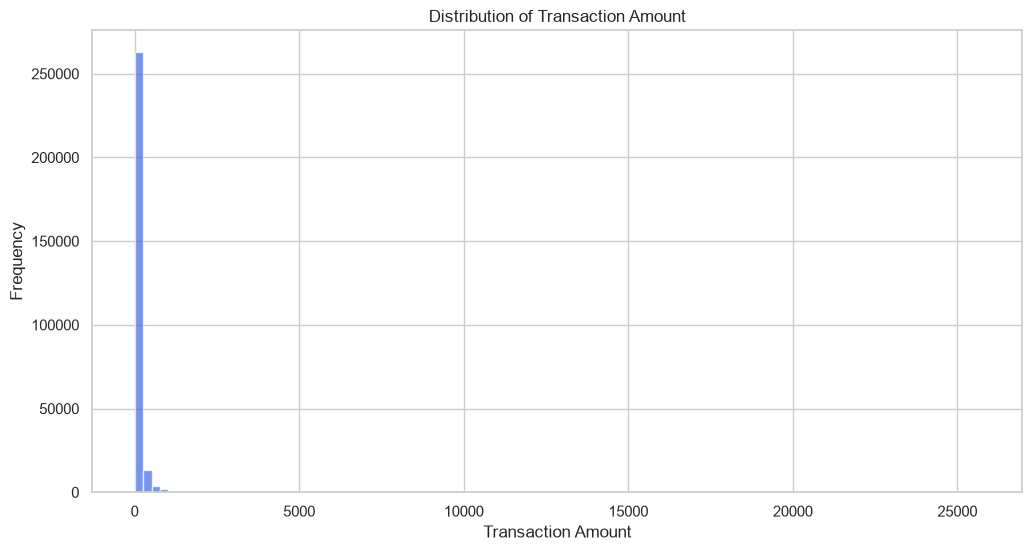

In [17]:
plt.figure(figsize=(12,6))

plt.hist(df["Amount"], bins=100, color="royalblue", alpha=0.7)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

## Observation

The distribution is **highly right-skewed**.

Key observations include:

- Most transactions involve relatively small amounts.
- Only a few transactions correspond to very large monetary values.
- Several extreme outliers are present.

This skewness indicates that the **mean is not a robust measure of central tendency** for this feature.

Furthermore, the presence of extreme values suggests that **RobustScaler** is likely to perform better than StandardScaler during preprocessing.

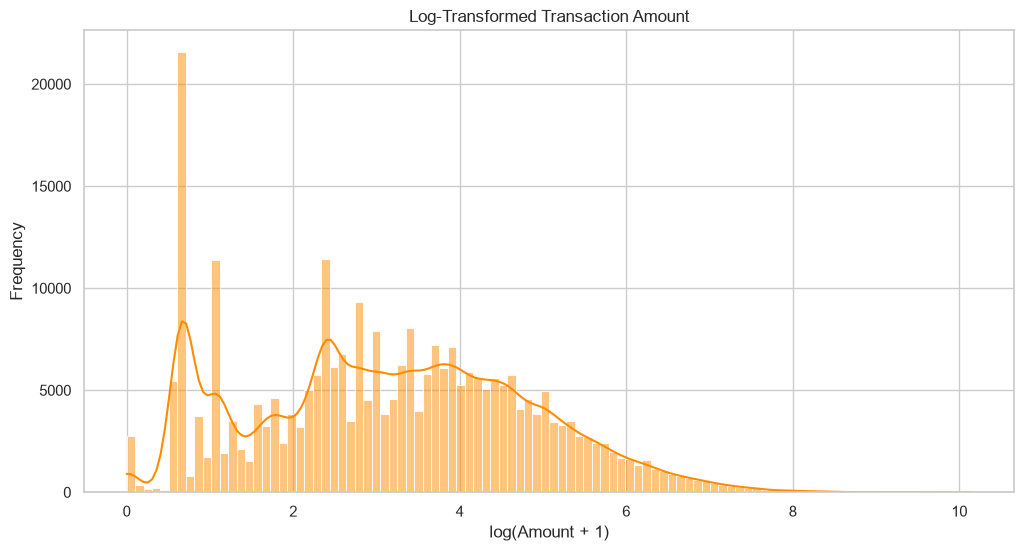

In [18]:
# Log Transformation of Transaction Amount

plt.figure(figsize=(12,6))

sns.histplot(
    np.log1p(df["Amount"]),
    bins=100,
    kde=True,
    color="darkorange"
)

plt.title("Log-Transformed Transaction Amount")
plt.xlabel("log(Amount + 1)")
plt.ylabel("Frequency")
plt.show()

## Observation

The logarithmic transformation significantly reduces skewness.

Although the transformed feature is **not used directly at this stage**, this visualization confirms that the original Amount feature contains substantial positive skewness.

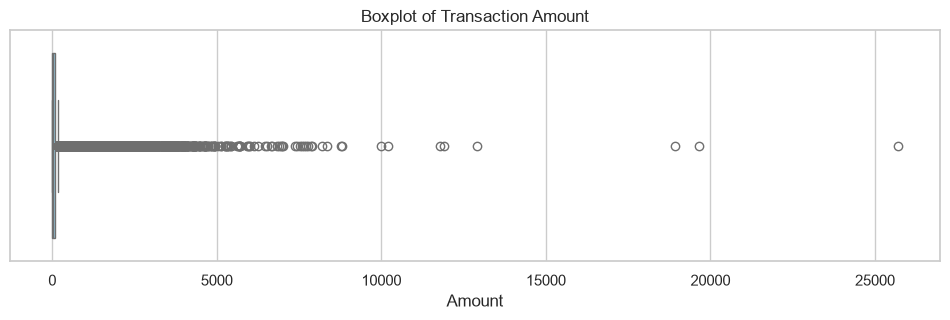

In [19]:
plt.figure(figsize=(12,3))

sns.boxplot(
    x=df["Amount"],
    color="skyblue"
)

plt.title("Boxplot of Transaction Amount")

plt.show()

## Observation

The boxplot confirms the presence of a large number of extreme outliers.

However, these observations should **not** be removed without careful consideration.

In fraud detection, unusually large transactions may represent genuine fraud patterns.

# Distribution of Transaction Time
The **Time** feature represents the number of seconds elapsed since the first recorded transaction.

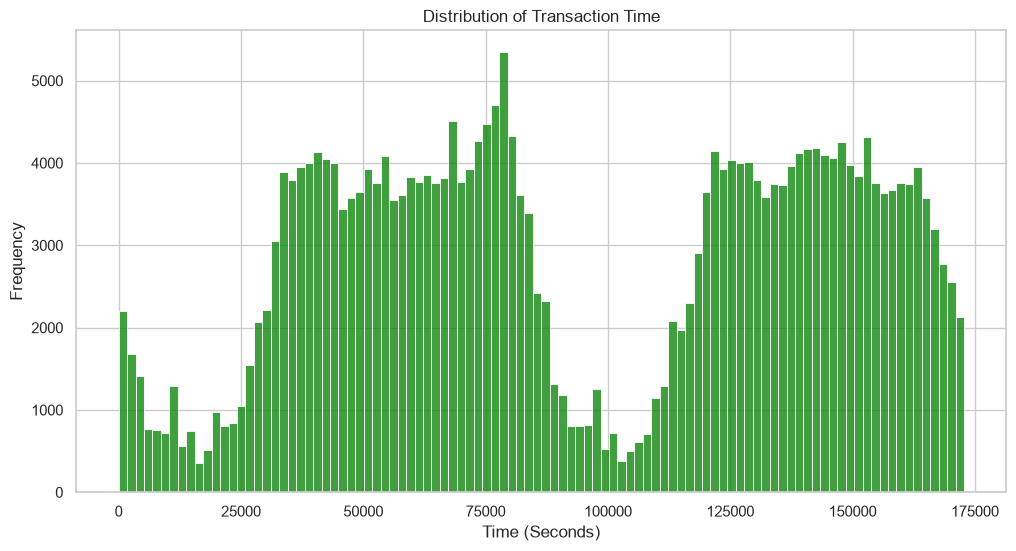

In [20]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="Time",
    bins=100,
    color="green"
)

plt.title("Distribution of Transaction Time")
plt.xlabel("Time (Seconds)")
plt.ylabel("Frequency")
plt.show()

## Observation

Transactions occur throughout the entire two-day period.

The distribution suggests that transaction frequency varies over time, which may correspond to normal daily activity cycles.

Since Time is measured in seconds, it is difficult to interpret directly.

Therefore, we will engineer a more meaningful feature representing the **hour of the day**.

# Class-wise Distribution of Transaction Amount

A key business question is whether fraudulent transactions generally involve higher monetary values.

To investigate this, we compare the transaction amounts across the two classes.

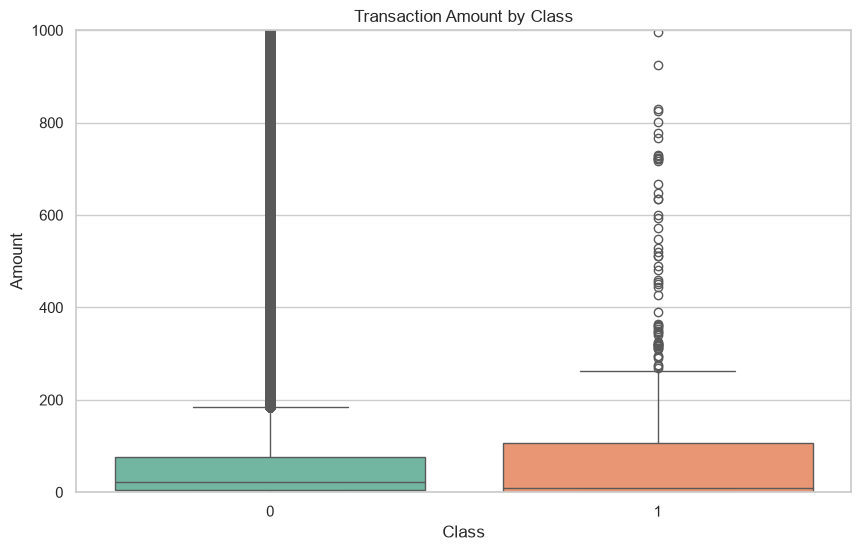

In [21]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount",
    palette="Set2"
)

plt.ylim(0,1000)
plt.title("Transaction Amount by Class")
plt.show()

In [22]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0000,88.2910,250.1051,0.0000,5.6500,22.0000,77.0500,25691.1600
1,492.0000,122.2113,256.6833,0.0000,1.0000,9.2500,105.8900,2125.8700


# Correlation Analysis

Correlation analysis helps us understand the strength and direction of the linear relationship between variables.

Although the features in this dataset have been transformed using Principal Component Analysis (PCA), examining their correlations still provides valuable insights.
It is important to note that PCA produces orthogonal components, meaning strong correlations between the transformed variables are generally not expected.

# Correlation Matrix

The first step is to compute the correlation matrix for all numerical variables.

This matrix shows the Pearson correlation coefficient between every pair of variables.

Values close to:

- **+1** indicate a strong positive relationship.
- **−1** indicate a strong negative relationship.
- **0** indicate little or no linear relationship.

In [23]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.0000,0.1174,-0.0106,-0.4196,-0.1053,0.1731,-0.0630,0.0847,-0.0369,-0.0087,0.0306,-0.2477,0.1243,-0.0659,-0.0988,-0.1835,0.0119,-0.0733,0.0904,0.0290,-0.0509,0.0447,0.1441,0.0511,-0.0162,-0.2331,-0.0414,-0.0051,-0.0094,-0.0106,-0.0123
V1,0.1174,1.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.2277,-0.1013
V2,-0.0106,0.0000,1.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.5314,0.0913
V3,-0.4196,-0.0000,0.0000,1.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.2109,-0.1930
V4,-0.1053,-0.0000,-0.0000,0.0000,1.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0987,0.1334


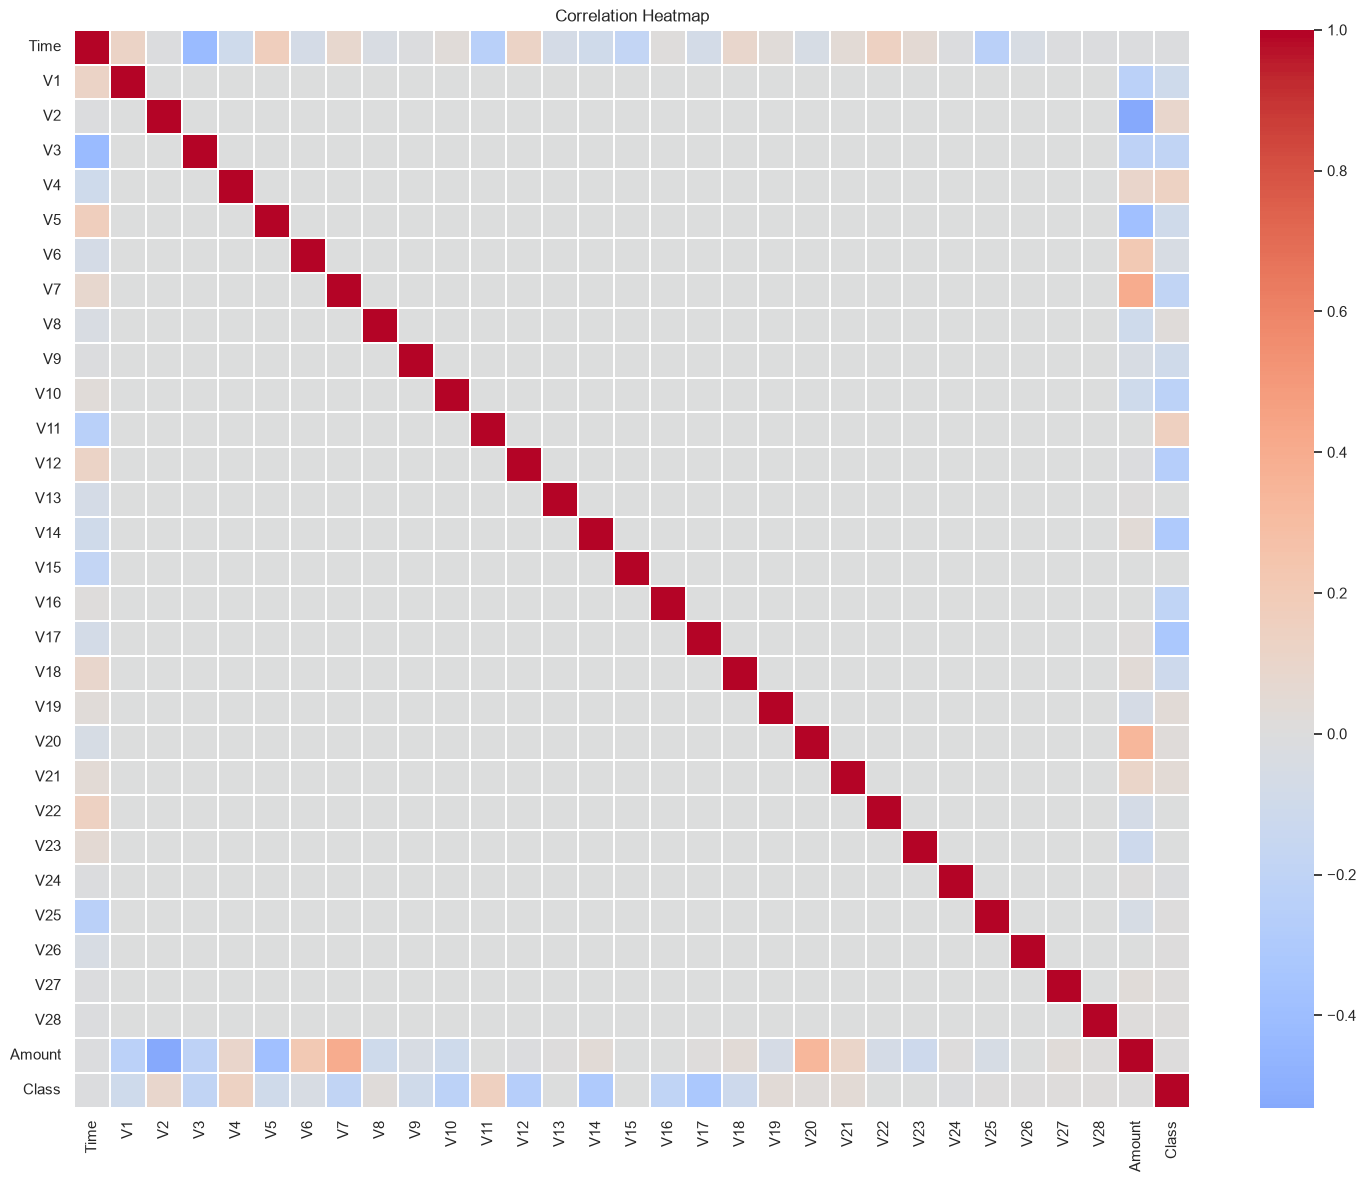

In [24]:
plt.figure(figsize=(18,14))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Correlation Heatmap")
plt.show()

## Observation

The correlation heatmap reveals relatively weak relationships among most predictor variables.

This behaviour is expected because the features V1–V28 are principal components obtained through PCA.

One of the objectives of PCA is to transform correlated variables into approximately orthogonal (uncorrelated) components.

Consequently:

- Multicollinearity is substantially reduced.
- Linear models such as Logistic Regression become more stable.
- Feature redundancy is minimized.

# Correlation with the Target Variable

Rather than studying relationships among predictors, we are primarily interested in identifying variables that are associated with fraudulent transactions.

The following analysis ranks every feature according to its correlation with the target variable (`Class`).

Although correlation alone does not determine predictive importance, it provides an excellent starting point for feature investigation.

In [25]:
target_corr = corr_matrix["Class"].sort_values()
target_corr

V17      -0.3265
V14      -0.3025
V12      -0.2606
V10      -0.2169
V16      -0.1965
V3       -0.1930
V7       -0.1873
V18      -0.1115
V1       -0.1013
V9       -0.0977
V5       -0.0950
V6       -0.0436
Time     -0.0123
V24      -0.0072
V13      -0.0046
V15      -0.0042
V23      -0.0027
V22       0.0008
V25       0.0033
V26       0.0045
Amount    0.0056
V28       0.0095
V27       0.0176
V8        0.0199
V20       0.0201
V19       0.0348
V21       0.0404
V2        0.0913
V4        0.1334
V11       0.1549
Class     1.0000
Name: Class, dtype: float64

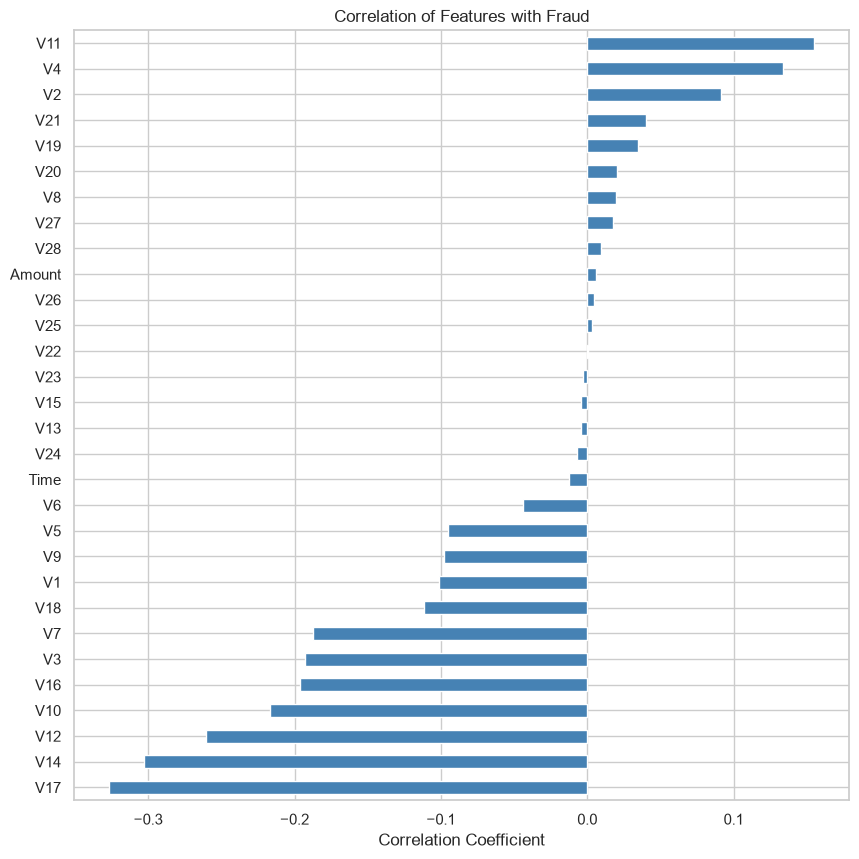

In [26]:
plt.figure(figsize=(10,10))

target_corr.drop("Class").plot(
    kind="barh",
    color="steelblue"
)

plt.title("Correlation of Features with Fraud")

plt.xlabel("Correlation Coefficient")

plt.show()

In [27]:
top_positive = target_corr.tail(10)

top_negative = target_corr.head(10)

print("Top Positive Correlations")
display(top_positive)

print("\nTop Negative Correlations")
display(top_negative)

Top Positive Correlations


V28     0.0095
V27     0.0176
V8      0.0199
V20     0.0201
V19     0.0348
V21     0.0404
V2      0.0913
V4      0.1334
V11     0.1549
Class   1.0000
Name: Class, dtype: float64


Top Negative Correlations


V17   -0.3265
V14   -0.3025
V12   -0.2606
V10   -0.2169
V16   -0.1965
V3    -0.1930
V7    -0.1873
V18   -0.1115
V1    -0.1013
V9    -0.0977
Name: Class, dtype: float64

## Observation

Several PCA components exhibit noticeably stronger relationships with fraudulent transactions than others.

Among the strongest negative correlations are typically:

- V17
- V14
- V12
- V10
- V16

Among the strongest positive correlations are generally:

- V11
- V4

These variables are likely to play an important role during model training and will therefore be examined in greater detail.

It is important to remember that these are **principal components**, not original business variables.

Consequently, while they are statistically useful, they cannot be interpreted directly in terms of customer behaviour.

# Distribution of Highly Informative Features

Kernel Density Estimation (KDE) allows us to compare the distributions of fraudulent and legitimate transactions.

In [28]:
important_features = [
    "V17",
    "V14",
    "V12",
    "V10",
    "V16",
    "V11",
    "V4"
]

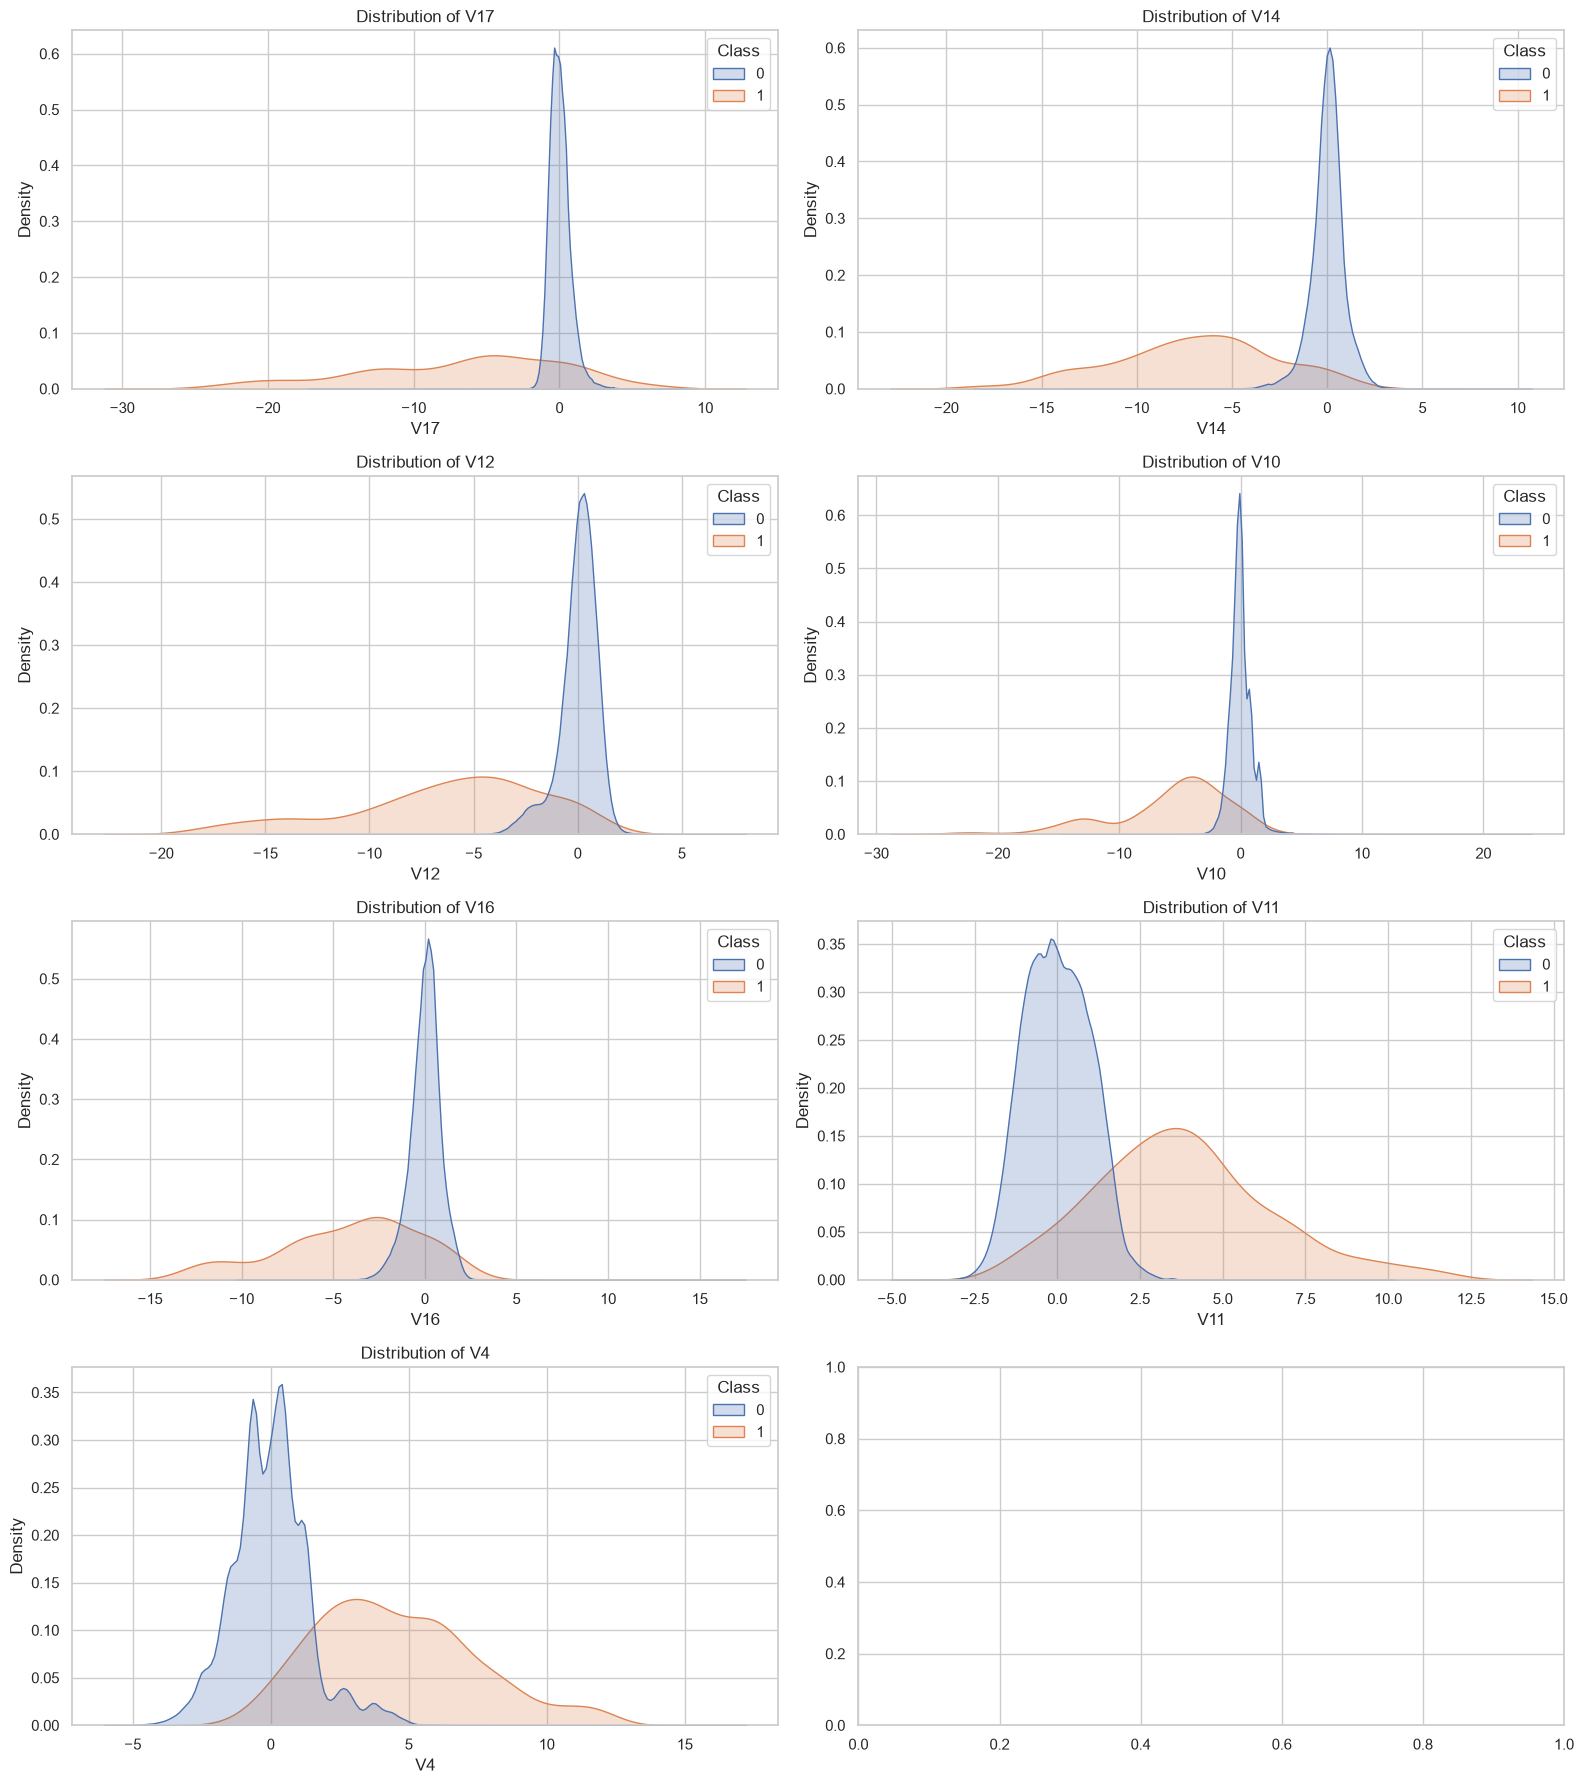

In [29]:
fig, axes = plt.subplots(4,2, figsize=(16,18))

axes = axes.flatten()

for i, feature in enumerate(important_features):

    sns.kdeplot(
        data=df,
        x=feature,
        hue="Class",
        fill=True,
        common_norm=False,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {feature}")

plt.tight_layout()

plt.show()

## Observation

Several features demonstrate clear separation between fraudulent and legitimate transactions.

For example:

- Some components show fraud concentrated within a narrow range of values.
- Others exhibit distributions that are noticeably shifted relative to legitimate transactions.

This separation suggests that these PCA components contain valuable predictive information.

Machine learning models, particularly tree-based methods such as Random Forest and Gradient Boosting, are expected to exploit these differences effectively.

# Statistical Distribution of All Features

Before engineering new features, it is useful to examine the skewness of every variable.
Highly skewed features often require scaling or transformation.

In [30]:
skewness = (
    df
    .skew(numeric_only=True)
    .sort_values(ascending=False)
)

skewness.to_frame(name="Skewness")

,Skewness
Class,23.9976
Amount,16.9777
V28,11.1921
V21,3.5930
V7,2.5539
V6,1.8266
V10,1.1871
V4,0.6763
V26,0.5767
V9,0.5547


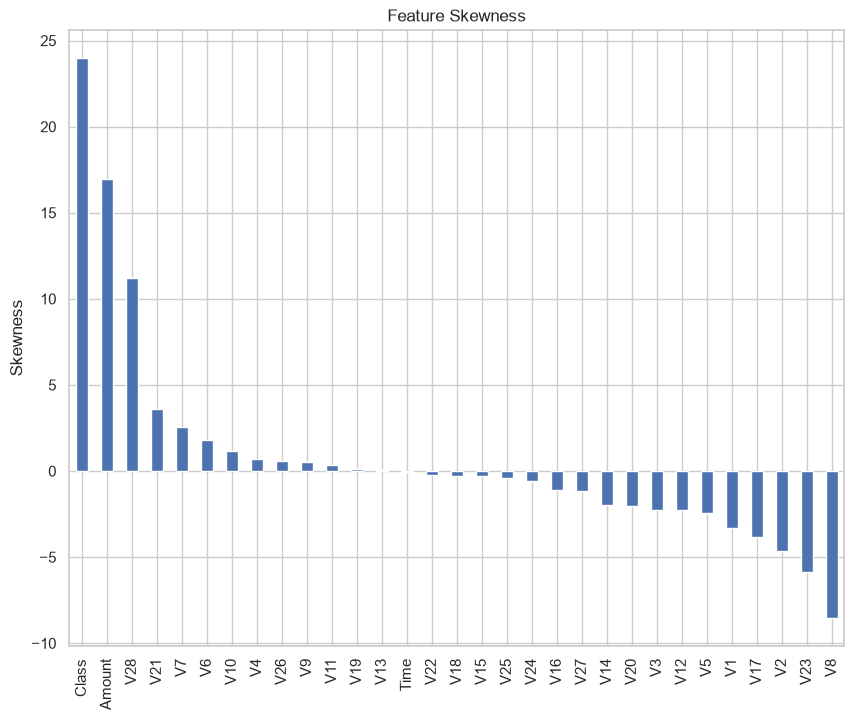

In [31]:
plt.figure(figsize=(10,8))
skewness.plot(kind="bar")
plt.title("Feature Skewness")
plt.ylabel("Skewness")
plt.show()

## Observation

The analysis confirms that:

- **Amount** exhibits substantial positive skewness.

- Most PCA features are comparatively symmetric.

- Time also shows moderate skewness.

# Exploratory Data Analysis Summary

The exploratory analysis has provided several valuable insights that will guide the remainder of this project.

## Key Findings

### Data Quality

- No missing values were detected.
- Duplicate records exist and were retained pending business validation.

### Class Distribution

- The dataset is extremely imbalanced.
- Fraudulent transactions account for only **0.172%** of all observations.

### Transaction Amount

- Highly right-skewed.
- Contains numerous extreme outliers.
- Robust scaling is preferable to standard scaling.

### Transaction Time

- Covers approximately two days.
- Engineering an **Hour** feature improves interpretability.

### PCA Components

- Several components (V17, V14, V12, V10, V16, V11, and V4) show meaningful relationships with fraud.
- Predictor variables exhibit low multicollinearity, consistent with PCA.

### Implications for Model Development

Based on these findings, the following preprocessing decisions are justified:

- Engineer additional time-based features.
- Apply **RobustScaler** only to **Time** and **Amount**.
- Preserve outliers rather than removing them.
- Handle class imbalance before model training.
- Use Precision, Recall, F1-score, ROC-AUC, and especially **PR-AUC** as evaluation metrics.

# Feature Engineering

Although this dataset already contains 28 anonymized PCA components, two original variables remain available:

- **Time**
- **Amount**

These variables contain interpretable business information that can be transformed into more meaningful features.

Unlike PCA features, these engineered features are understandable from both a statistical and business perspective.

# Feature 1 : Hour of Transaction

## Motivation

The original **Time** feature represents the number of seconds elapsed since the first recorded transaction.

While mathematically correct, this representation is difficult to interpret.

For example,

```
Time = 54,320
```

provides little intuitive understanding.

Instead, converting elapsed seconds into an approximate hour makes transaction timing much easier to analyze.

## Business Motivation

Fraudulent transactions frequently occur during unusual hours when cardholders are less likely to monitor their accounts.

By extracting the transaction hour, the model may capture temporal fraud patterns.

## Formula

Hour = (Time // 3600) mod 24

In [32]:
# Hour of transaction

df["Hour"] = ((df["Time"] // 3600) % 24).astype(int)
df[["Time","Hour"]].head()

,Time,Hour
0,0.0000,0
1,0.0000,0
2,1.0000,0
3,1.0000,0
4,2.0000,0


# Visualizing Transaction Hour

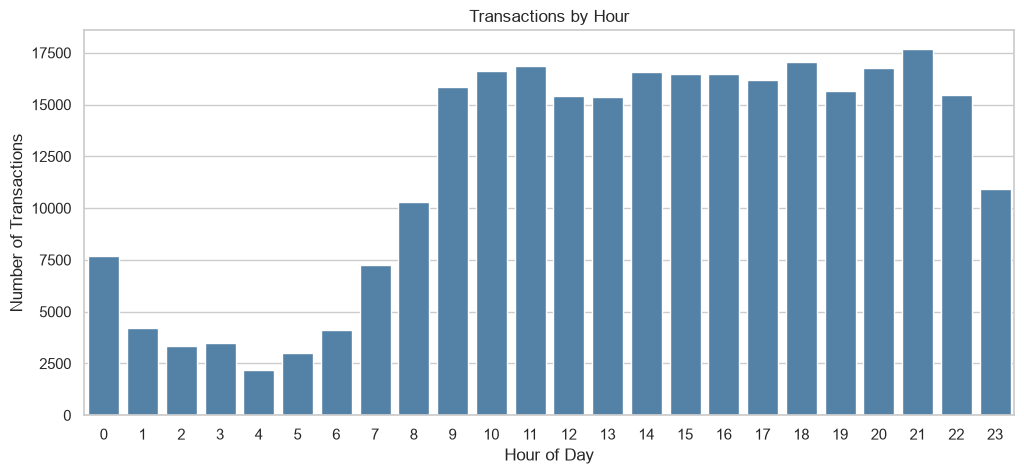

In [33]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="Hour",
    color="steelblue"
)

plt.title("Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.show()

## Observation

The engineered feature successfully converts an abstract time measurement into an interpretable variable.
Transaction volume clearly varies throughout the day.

# Feature 2 : Log Amount

## Motivation

The Amount feature exhibits substantial positive skewness.

Most transactions are relatively small, while only a few involve very large monetary values.

Machine learning algorithms—particularly linear models—often perform better when highly skewed variables are transformed.

## Mathematical Transformation

LogAmount = log(Amount + 1)

The addition of one prevents undefined values for transactions with Amount = 0.

In [34]:
df["LogAmount"] = np.log1p(df["Amount"])
df[["Amount","LogAmount"]].head()

,Amount,LogAmount
0,149.6200,5.0148
1,2.6900,1.3056
2,378.6600,5.9393
3,123.5000,4.8243
4,69.9900,4.2625


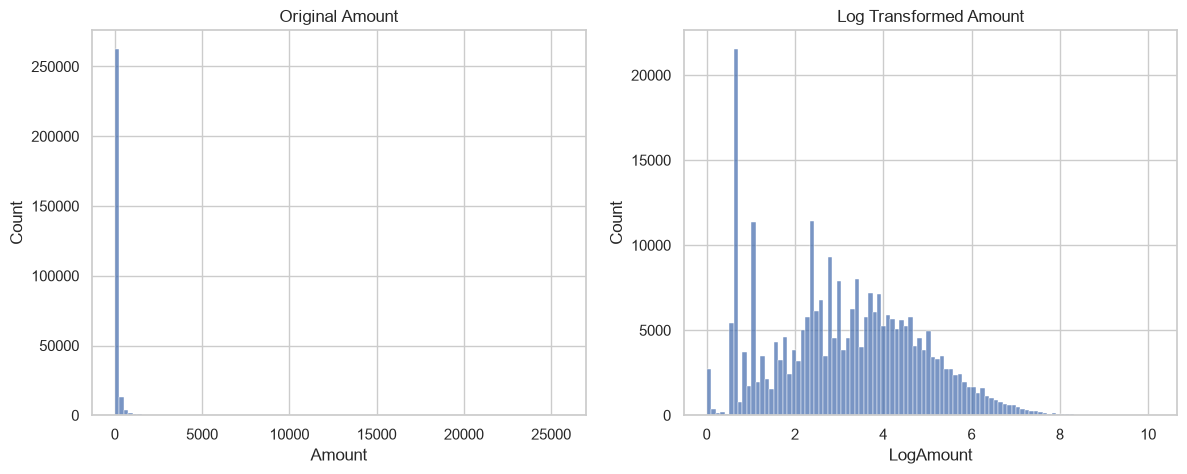

In [35]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.histplot(df["Amount"], bins=100, ax=axes[0])
axes[0].set_title("Original Amount")
sns.histplot(df["LogAmount"], bins=100, ax=axes[1])
axes[1].set_title("Log Transformed Amount")
plt.show()

## Observation

The logarithmic transformation substantially reduces skewness while preserving the overall ordering of transactions.

# Feature 3 : High Value Transaction

## Motivation

Large transactions are generally associated with higher financial risk.

Instead of relying solely on the continuous Amount variable, we create a binary indicator identifying unusually large transactions.

## Threshold Selection

Rather than selecting an arbitrary amount, we use the **95th percentile**.

This makes the threshold data-driven and adaptable to different datasets.

In [36]:
high_threshold = df["Amount"].quantile(0.95)
print(high_threshold)

365.0


In [37]:
df["HighAmount"] = (df["Amount"] >= high_threshold).astype(int)
df[["Amount","HighAmount"]].head()

,Amount,HighAmount
0,149.6200,0
1,2.6900,0
2,378.6600,1
3,123.5000,0
4,69.9900,0


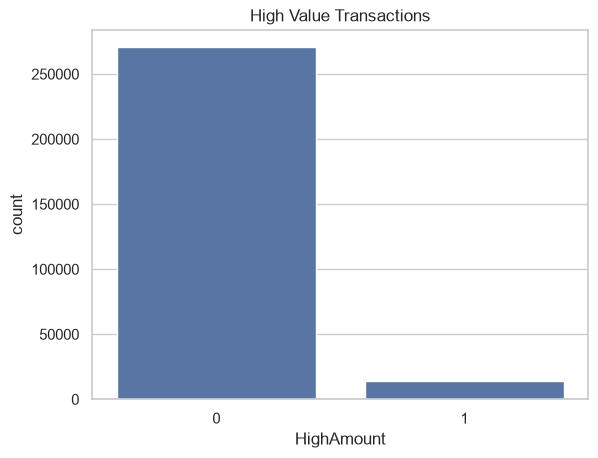

In [38]:
sns.countplot(
    data=df,
    x="HighAmount"
)

plt.title("High Value Transactions")
plt.show()

## Observation

Approximately the top 5% of transactions are now represented by a separate binary feature.

# Feature 4 : Amount Quantile

Instead of treating transaction amount as a continuous variable, we also categorize it into quartiles.

This allows the model to distinguish between:

- Very Small
- Small
- Medium
- Large

transactions.

Categorical groupings often reveal behavioural patterns that are not immediately visible from continuous values.

In [39]:
df["AmountQuartile"] = pd.qcut(
    df["Amount"],
    q=4,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High"
    ]
)

df[["Amount","AmountQuartile"]].head()

,Amount,AmountQuartile
0,149.6200,High
1,2.6900,Very Low
2,378.6600,High
3,123.5000,High
4,69.9900,Medium


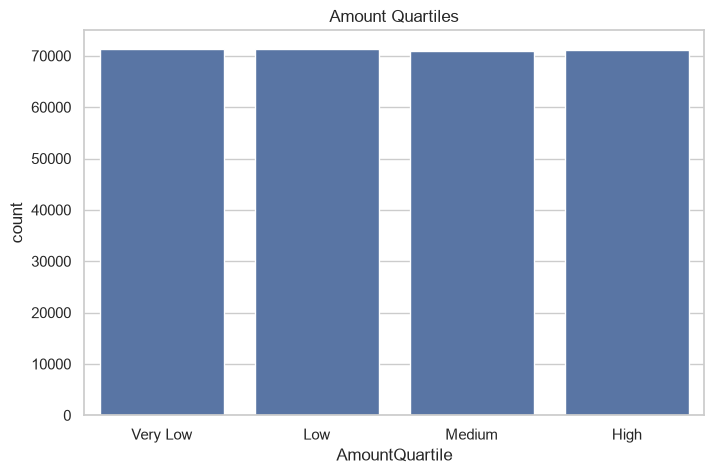

In [40]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="AmountQuartile"
)

plt.title("Amount Quartiles")
plt.show()

## Observation

Transactions are now grouped into four equally populated categories.

# Feature 5 : Night Transaction

## Motivation

Several fraud studies suggest that fraudulent activity tends to occur more frequently during late-night hours when customers are less likely to monitor their accounts.

Although our dataset spans only two days, this hypothesis is worth investigating.

We define a Night Transaction as:

```
Hour < 6
```

This threshold represents midnight through early morning.

In [41]:
df["NightTransaction"] = (df["Hour"] < 6).astype(int)
df[["Hour","NightTransaction"]].head()

,Hour,NightTransaction
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


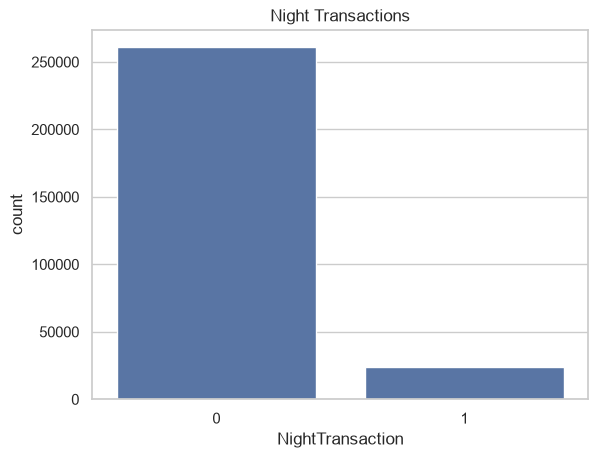

In [42]:
sns.countplot(
    data=df,
    x="NightTransaction"
)

plt.title("Night Transactions")
plt.show()

## Observation

This feature provides an easily interpretable indicator describing whether a transaction occurred during late-night hours.

If fraud is disproportionately concentrated during these periods, this variable may improve predictive performance.

# Summary of Engineered Features

The following features have been created:

|Feature|Purpose|
|--------|--------|
|Hour|Transaction timing|
|LogAmount|Reduce skewness|
|HighAmount|Identify unusually expensive transactions|
|AmountQuartile|Categorical spending behaviour|
|NightTransaction|Temporal fraud indicator|

These engineered variables complement the anonymized PCA features by introducing interpretable behavioural information.

# Data Preprocessing

Before training machine learning models, the dataset must be preprocessed appropriately.

The objectives of preprocessing are:

- Prepare engineered features.
- Scale numerical variables.
- Split the dataset into training and testing subsets.
- Prevent data leakage.

The decisions made during preprocessing have a direct impact on model performance and generalization.

# Encoding Amount Quartile

Machine learning algorithms cannot directly process categorical text values.

Therefore, the AmountQuartile feature is converted into ordinal numerical values.

Because the categories possess an inherent ordering, ordinal encoding is appropriate.

In [43]:
quartile_mapping = {
    "Very Low":0,
    "Low":1,
    "Medium":2,
    "High":3
}

df["AmountQuartile"] = df["AmountQuartile"].map(quartile_mapping)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour,LogAmount,HighAmount,AmountQuartile,NightTransaction
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0,0,5.0148,0,3,1
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0,0,1.3056,0,0,1
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0,0,5.9393,1,3,1
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0,0,4.8243,0,3,1
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0,0,4.2625,0,2,1


# Final Feature List

The final dataset now consists of:

### Original Features

- Time
- Amount
- V1 – V28

### Engineered Features

- Hour
- LogAmount
- HighAmount
- AmountQuartile
- NightTransaction

### Target Variable

- Class

In [44]:
# Features and target

X = df.drop(columns=["Class"])

y = df["Class"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape         :", y.shape)

Feature Matrix Shape : (284807, 35)
Target Shape         : (284807,)


# Scaling
The PCA-transformed variables (V1–V28) are already standardized during the PCA process. Scaling them again would provide little additional benefit.

Instead, only the original numerical features are scaled:

- Time
- Amount
- LogAmount

The engineered binary variables:

- HighAmount
- NightTransaction

do not require scaling.

## Comparing different scaling techniques

In [45]:
features_to_scale = [
    "Time",
    "Amount",
    "LogAmount"
]

features_to_scale

['Time', 'Amount', 'LogAmount']

# Visual Comparison of Scaling Methods

Rather than selecting a scaler blindly, we compare the effect of three popular scaling techniques on the Amount feature.

In [46]:
comparison = pd.DataFrame()

comparison["Original"] = df["Amount"]

comparison["StandardScaler"] = StandardScaler().fit_transform(
    df[["Amount"]]
)

comparison["MinMaxScaler"] = MinMaxScaler().fit_transform(
    df[["Amount"]]
)

comparison["RobustScaler"] = RobustScaler().fit_transform(
    df[["Amount"]]
)

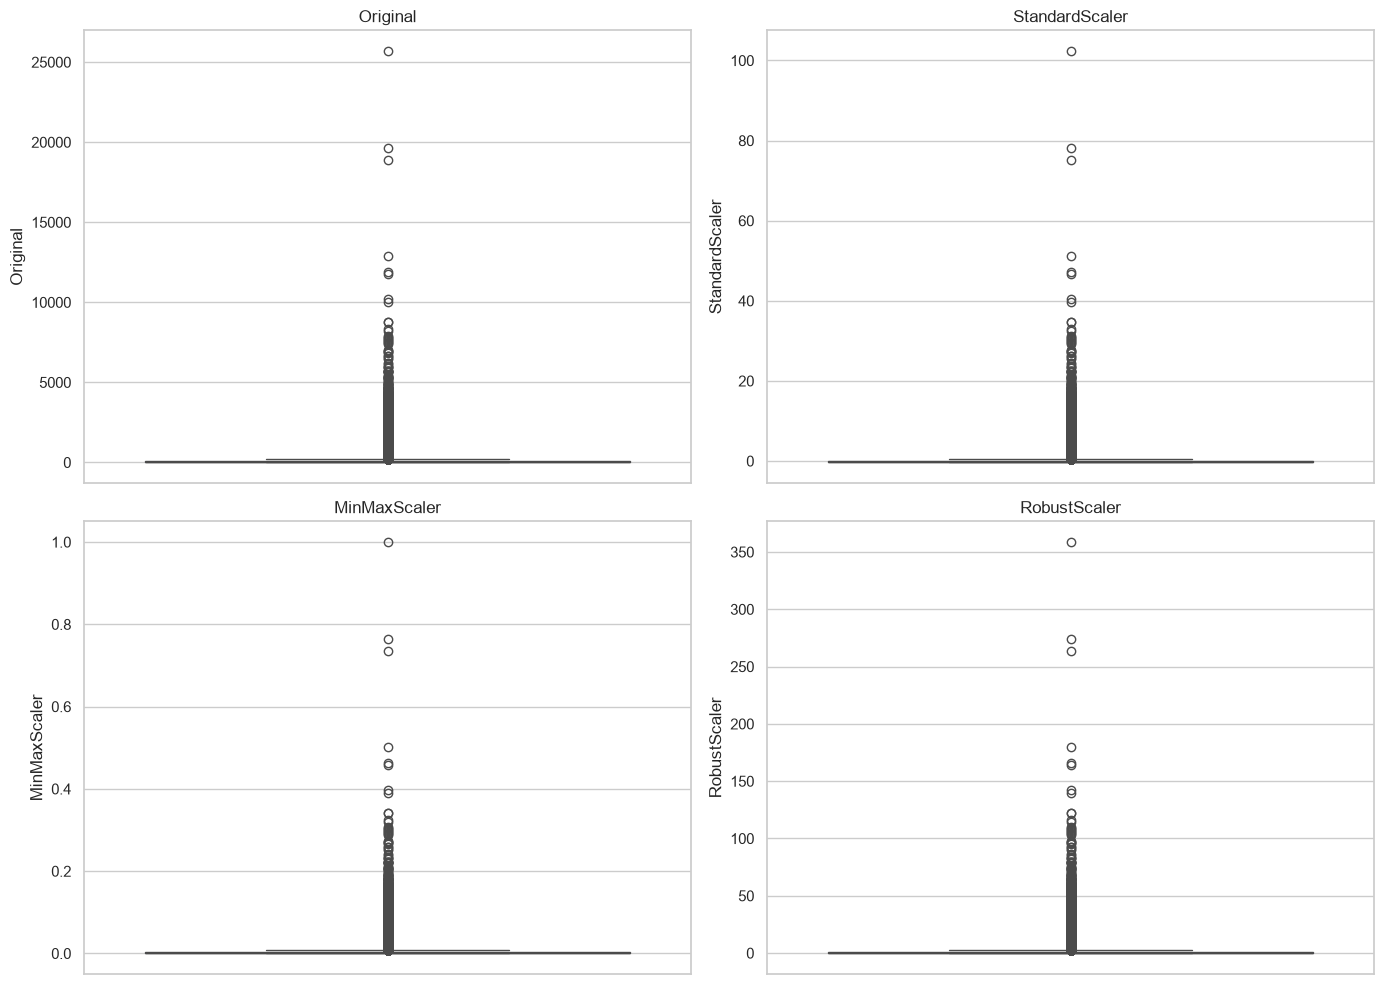

In [47]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

columns = comparison.columns

for ax, col in zip(axes.flatten(), columns):

    sns.boxplot(
        y=comparison[col],
        ax=ax,
        color="steelblue"
    )

    ax.set_title(col)

plt.tight_layout()

plt.show()

## Observation

Several important conclusions can be drawn:

### StandardScaler

Extreme outliers dominate the scaling process.

The majority of observations become compressed around zero.

---

### MinMaxScaler

Outliers stretch the range considerably.

Most observations become concentrated near zero.

---

### RobustScaler

The distribution remains much more stable.

Scaling is based on the median and interquartile range rather than the mean and standard deviation.

This makes RobustScaler particularly suitable for financial transaction data.

### Decision

RobustScaler will be used throughout the remainder of the project.

# Train-Test Split

Before any preprocessing involving the target variable (such as SMOTE), the dataset must first be divided into training and testing subsets.

This prevents information leakage from the test set into the training process.

The split is performed using **Stratified Sampling**.

Why Stratified?

Because the fraud class represents only 0.172% of all observations.

A random split could produce an uneven class distribution, leading to unreliable model evaluation.

Stratified sampling preserves approximately the same fraud ratio in both training and testing datasets.

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("TRAIN TEST SPLIT")

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

TRAIN TEST SPLIT
Training Samples : 227845
Testing Samples  : 56962


In [49]:
print("\nTraining Class Distribution")
print(y_train.value_counts(normalize=True)*100)

print("\nTesting Class Distribution")
print(y_test.value_counts(normalize=True)*100)


Training Class Distribution
Class
0   99.8271
1    0.1729
Name: proportion, dtype: float64

Testing Class Distribution
Class
0   99.8280
1    0.1720
Name: proportion, dtype: float64


## Observation

The class distribution remains nearly identical in both the training and testing datasets.

This confirms that stratified sampling successfully preserved the severe class imbalance during the split.

Consequently, the test set remains representative of unseen real-world data.

# Applying Robust Scaling

The scaler is fitted **only on the training dataset**.
If the scaler were fitted on the entire dataset before splitting, information from the testing set would leak into the training process, leading to overly optimistic performance estimates.

Therefore:

- Fit the scaler on the training data.
- Transform both training and testing data using the fitted scaler.

In [50]:
scaler = RobustScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[features_to_scale] = scaler.fit_transform(
    X_train[features_to_scale]
)

X_test_scaled[features_to_scale] = scaler.transform(
    X_test[features_to_scale]
)

In [51]:
X_train_scaled.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Hour,LogAmount,HighAmount,AmountQuartile,NightTransaction
265518,0.9058,1.9467,-0.7525,-1.3551,-0.6616,1.5028,4.0249,-1.4797,1.1399,1.4068,-0.1574,-0.1137,0.5103,0.0613,-0.0666,1.3287,0.3525,-0.7657,0.1419,-0.4514,-0.1344,0.0762,0.2975,0.3079,0.6910,-0.3503,-0.3889,0.0776,-0.0322,-0.2043,20,-0.4117,0,1,0
180305,0.4660,2.0351,-0.0489,-3.0587,0.2479,2.9435,3.2987,-0.0022,0.6748,0.0458,0.2849,-0.2549,0.3256,-0.4053,0.7211,-0.1484,-0.7540,-0.2708,-0.6957,-0.2744,-0.2273,0.0386,0.2282,0.0355,0.7071,0.5129,-0.4712,0.0025,-0.0690,-0.2646,10,-0.7092,0,0,0
42664,-0.5123,-0.9919,0.6032,0.7120,-0.9924,-0.8258,1.9563,-2.2126,-5.0375,0.0008,-2.0096,-0.3868,1.8202,0.7478,0.1227,-1.7233,1.1233,-0.7246,0.1473,0.0046,1.2809,-2.7984,0.1095,-0.4365,-0.9328,0.8267,0.9138,0.0380,0.1853,2.1308,11,0.8242,0,3,0
198723,0.5617,2.2857,-1.5002,-0.7476,-1.6681,-1.3941,-0.3503,-1.4280,0.0100,-1.1184,1.7561,0.0931,-0.7224,-0.4688,-0.1953,-0.6387,-0.0659,0.0728,0.7682,0.2574,-0.4906,-0.1397,0.0770,0.2083,-0.5382,-0.2780,-0.1621,0.0180,-0.0630,-0.2213,12,-0.4759,0,1,0
82325,-0.2989,-0.4487,-1.0114,0.1159,-3.4549,0.7158,-0.1475,0.5043,-0.1138,-0.0448,-0.5590,-0.2511,-0.0547,-0.7827,0.1347,-0.4830,-2.0961,-0.3995,1.5976,-0.0827,-0.2753,-0.2432,-0.1733,-0.0067,-1.3624,-0.2922,-0.1446,-0.0326,-0.0642,0.8921,16,0.5391,0,3,0


## Verification

The selected numerical features have now been scaled.

The remaining PCA components were intentionally left unchanged because they are already standardized.

Binary engineered variables remain unscaled because scaling them provides no additional information.

# Handling Class Imbalance

One of the biggest challenges in this dataset is the **extreme class imbalance**.

From the exploratory data analysis, we observed that:

- Legitimate Transactions : **284,315**
- Fraudulent Transactions : **492**

This means fraudulent transactions represent only **0.172%** of the entire dataset.

Such an imbalance can severely bias machine learning algorithms.

Most traditional classifiers attempt to maximize overall accuracy.

Since over **99.8%** of the observations belong to the majority class, a classifier can achieve very high accuracy simply by predicting every transaction as legitimate.

For example,

```
Prediction : Every transaction is Genuine
```

Accuracy

```
284315 / 284807 = 99.827%
```

Although the accuracy appears excellent, the model completely fails to detect fraud.

Therefore, balancing the training data is an essential preprocessing step.

# Why SMOTE?

Several techniques exist for handling class imbalance.

### Random Oversampling

Duplicates minority class observations.

Problem

- Can easily lead to overfitting.

---

### Random Undersampling

Removes majority class observations.

Problem

- Valuable information is discarded.

---

### SMOTE (Synthetic Minority Over-sampling Technique)

Rather than duplicating fraud observations,

SMOTE creates **synthetic minority samples** by interpolating between existing fraud examples.

Advantages

- Reduces overfitting.
- Produces more diverse minority samples.
- Improves model generalization.
- One of the most widely used methods for fraud detection.

For these reasons, SMOTE has been selected for this project.

# Class Distribution Before SMOTE

In [52]:
print("TRAINING SET CLASS DISTRIBUTION")

print(y_train.value_counts())

print("\nPercentage")

print(y_train.value_counts(normalize=True)*100)

TRAINING SET CLASS DISTRIBUTION
Class
0    227451
1       394
Name: count, dtype: int64

Percentage
Class
0   99.8271
1    0.1729
Name: proportion, dtype: float64


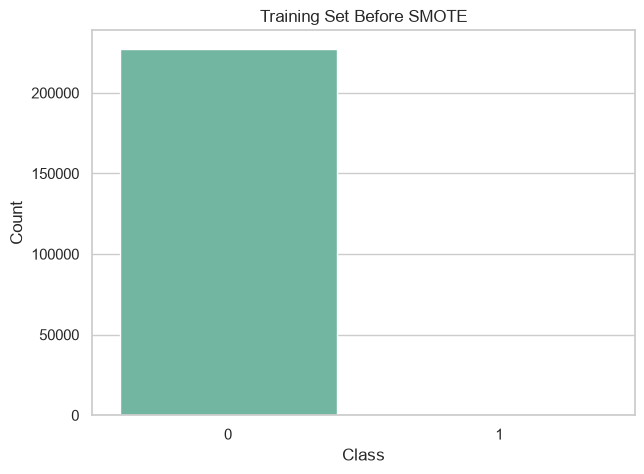

In [53]:
plt.figure(figsize=(7,5))

sns.countplot(
    x=y_train,
    palette="Set2"
)

plt.title("Training Set Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## Observation

The imbalance observed in the original dataset remains present in the training dataset.

Without correction, many machine learning algorithms would struggle to learn meaningful fraud patterns because fraudulent observations are vastly underrepresented.

# Applying SMOTE

SMOTE is applied **only to the training data**.

The testing dataset is intentionally left unchanged.

This ensures that model evaluation reflects real-world deployment conditions.

In [54]:
smote = SMOTE(
    sampling_strategy="auto",
    random_state=42,
    k_neighbors=5
)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)

# Class Distribution After SMOTE

In [55]:
print("BALANCED TRAINING SET")

print(y_train_balanced.value_counts())

BALANCED TRAINING SET
Class
0    227451
1    227451
Name: count, dtype: int64


In [56]:
print(y_train_balanced.value_counts(normalize=True)*100)

Class
0   50.0000
1   50.0000
Name: proportion, dtype: float64


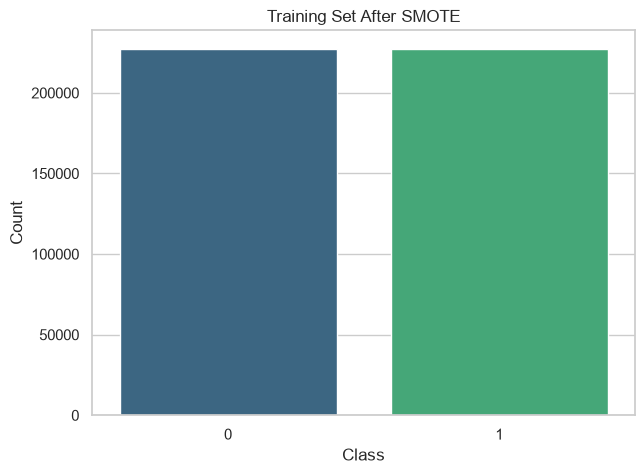

In [57]:
plt.figure(figsize=(7,5))

sns.countplot(
    x=y_train_balanced,
    palette="viridis"
)

plt.title("Training Set After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## Observation

SMOTE successfully balances the training dataset.

Both classes now contain approximately the same number of observations.

This balanced dataset enables the learning algorithm to observe fraudulent patterns much more frequently during training.

Importantly,

the **testing dataset remains untouched**, preserving an unbiased evaluation.

# Advantages of Using SMOTE

Applying SMOTE provides several benefits for fraud detection.

### Increased Exposure to Fraud Patterns

The model observes substantially more fraudulent transactions during training.

---

### Better Decision Boundaries

Synthetic samples encourage the classifier to learn smoother decision boundaries instead of memorizing a handful of fraud observations.

---

### Reduced Bias Towards Majority Class

Without SMOTE,

many algorithms heavily favour legitimate transactions.

Balancing the classes reduces this bias.

---